<a href="https://colab.research.google.com/github/psvprasad2003/DS_AI_CB/blob/main/IIMV_GS_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generate solve problem
You have been asked by one of the FRF clients to develop period rates, asset prices and scrap price forecasting models in line with the FRF models  
With below assumption ‌
List of Assumptions for Data Science
A1: I work for a Data Science firm/team; rest is just trivia
A2: I am a Data Scientist; I don’t need anybody else
A3: Data is available & true
A4: Data accurately represents the business process
A5: Historical data (training) is a good indicator of future (test) values (business process is constant)
A6. The model is unique, readily available, better than naïve (simple/inexpensive model) and explainable
A7. Predictors are readily available
A8. Only one model performance is good enough
A9. Cost, pricing, revenue, market acceptance and compliance are not my concern


In [ ]:
# @title AI prompt cell

import ipywidgets as widgets
from IPython.display import display, HTML, Markdown,clear_output
from google.colab import ai

dropdown = widgets.Dropdown(
    options=[],
    layout={'width': 'auto'}
)

def update_model_list(new_options):
    dropdown.options = new_options
update_model_list(ai.list_models())

text_input = widgets.Textarea(
    placeholder='Ask me anything....',
    layout={'width': 'auto', 'height': '100px'},
)

button = widgets.Button(
    description='Submit Text',
    disabled=False,
    tooltip='Click to submit the text',
    icon='check'
)

output_area = widgets.Output(
     layout={'width': 'auto', 'max_height': '300px','overflow_y': 'scroll'}
)

def on_button_clicked(b):
    with output_area:
        output_area.clear_output(wait=False)
        accumulated_content = ""
        for new_chunk in ai.generate_text(prompt=text_input.value, model_name=dropdown.value, stream=True):
            if new_chunk is None:
                continue
            accumulated_content += new_chunk
            clear_output(wait=True)
            display(Markdown(accumulated_content))

button.on_click(on_button_clicked)
vbox = widgets.GridBox([dropdown, text_input, button, output_area])

display(HTML("""
<style>
.widget-dropdown select {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
.widget-textarea textarea {
    font-size: 18px;
    font-family: "Arial", sans-serif;
}
</style>
"""))
display(vbox)


GridBox(children=(Dropdown(layout=Layout(width='auto'), options=('google/gemini-2.5-flash-lite', 'google/gemin…

Generate code for below scenario

In [ ]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


def generate_mock_data(n_periods=1000):
    """Generates synthetic data for period rates, asset prices, and scrap prices."""
    np.random.seed(42)
    dates = pd.date_range(start="2020-01-01", periods=n_periods, freq="D")

    # Simulating continuous economic data stream
    period_rates = 2.5 + np.cumsum(np.random.normal(0, 0.05, n_periods))
    asset_prices = 100 + np.cumsum(np.random.normal(0.1, 1.2, n_periods))
    scrap_prices = (
        asset_prices * 0.15 + np.random.normal(0, 2, n_periods)
    )  # Highly correlated to asset price

    df = pd.DataFrame(
        {
            "date": dates,
            "period_rate": period_rates,
            "asset_price": asset_prices,
            "scrap_price": scrap_prices,
        }
    )
    return df.set_index("date")

In [ ]:
def create_features(df, target_col, lags=[1, 2, 3, 7], windows=[7, 30]):
    """Engineers lag and rolling window features for time series forecasting."""
    X = pd.DataFrame(index=df.index)

    # Historical lag features
    for lag in lags:
        X[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)

    # Rolling statistics features
    for w in windows:
        X[f"{target_col}_roll_mean_{w}"] = (
            df[target_col].shift(1).rolling(window=w).mean()
        )
        X[f"{target_col}_roll_std_{w}"] = (
            df[target_col].shift(1).rolling(window=w).std()
        )

    # Target variable
    y = df[target_col]

    # Dropping rows with NaN values caused by shifting/rolling
    valid_idx = X.dropna().index
    return X.loc[valid_idx], y.loc[valid_idx]

In [ ]:
def train_and_forecast(X, y, test_size=180):
    """Trains a LightGBM Regressor and evaluates performance on a holdout test set."""
    # Time-series split (Train / Test)
    X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # Model initializing (Explainable, fast, and beats naive models)
    model = LGBMRegressor(
        n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1
    )
    model.fit(X_train, y_train)

    # Predictions
    predictions = model.predict(X_test)

    # Evaluation Metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mape = mean_absolute_percentage_error(y_test, predictions)

    # Feature Importance Mapping (Explainability aspect)
    importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False
    )

    return predictions, y_test, {"RMSE": rmse, "MAPE": mape}, importance

In [ ]:
# ==========================================
# BASELINE EXECUTION PIPELINE
# ==========================================
print("--- Baseline FRF Forecasting Models Initialization ---")

# 1. Load Data
data = generate_mock_data()
targets = ["period_rate", "asset_price", "scrap_price"]

baseline_mape = {}

for target in targets:
    print(f"\nBuilding forecasting model for: {target.upper()}")

    # 2. Feature Engineering
    X, y = create_features(data, target_col=target)

    # 3. Model Training & Evaluation
    preds, true_values, metrics, feature_imp = train_and_forecast(X, y)

    # 4. Display Results
    print(f"  [+] Evaluation -> RMSE: {metrics['RMSE']:.4f} | MAPE: {metrics['MAPE']*100:.2f}%")
    print(f"  [+] Top Predictor: {feature_imp.index[0]} (Score: {feature_imp.values[0]})")
    print("-" * 50)
    baseline_mape[target] = metrics['MAPE']

print(f"Baseline MAPE for scrap_price: {baseline_mape['scrap_price']*100:.2f}%")

--- Baseline FRF Forecasting Models Initialization ---

Building forecasting model for: PERIOD_RATE
  [+] Evaluation -> RMSE: 0.3560 | MAPE: 7.96%
  [+] Top Predictor: period_rate_lag_1 (Score: 737)
--------------------------------------------------

Building forecasting model for: ASSET_PRICE
  [+] Evaluation -> RMSE: 7.7373 | MAPE: 1.82%
  [+] Top Predictor: asset_price_lag_1 (Score: 999)
--------------------------------------------------

Building forecasting model for: SCRAP_PRICE
  [+] Evaluation -> RMSE: 3.0816 | MAPE: 6.17%
  [+] Top Predictor: scrap_price_roll_std_30 (Score: 421)
--------------------------------------------------
Baseline MAPE for scrap_price: 6.17%


### Improving MAPE for the `scrap_price` Model

To improve the Mean Absolute Percentage Error (MAPE) for your `scrap_price` forecasting model, you can focus on several key areas:

1.  **Enhanced Feature Engineering**: The current `create_features` function only uses lagged values and rolling statistics of the target variable itself. Given that `scrap_price` is highly correlated with `asset_price` (as stated in `generate_mock_data`), incorporating `asset_price` as an *exogenous feature* will likely significantly improve the model.
    *   **Additional Lags**: Experiment with a wider range of lag values for both the target and exogenous variables.
    *   **More Rolling Statistics**: Beyond mean and standard deviation, consider median, min, max, and quantiles for rolling windows.
    *   **Time-based Features**: For real-world data, features like day of week, month, quarter, year, holidays, and business day indicators can capture seasonality and cyclical patterns.
    *   **Interaction Features**: Create new features by combining existing ones (e.g., `lagged_scrap_price * lagged_asset_price`).

2.  **Hyperparameter Tuning**: The `LGBMRegressor` has many parameters that can be optimized to improve performance. Common parameters to tune include:
    *   `n_estimators`: Number of boosting rounds.
    *   `learning_rate`: Step size shrinkage used in updating weights.
    *   `num_leaves`: Max number of leaves in one tree.
    *   `max_depth`: Max tree depth for base learners.
    *   `min_child_samples`: Minimum number of data needed in a child (leaf).
    *   `subsample`: Subsample ratio of the training instance.
    *   `colsample_bytree`: Subsample ratio of columns when constructing each tree.

3.  **Ensemble Methods**: Combine predictions from multiple models (e.g., different LGBM models with varying features or hyperparameters, or even different algorithms like ARIMA or Prophet).

4.  **Outlier Handling**: Identify and treat outliers in your data, as they can disproportionately affect tree-based models.

5.  **Longer Training Data**: More historical data, if available and relevant, can help models learn more complex patterns.

Let's implement improved feature engineering and manual hyperparameter tuning for the `scrap_price` model.

### Feature Engineering Improvement for `scrap_price`

We'll modify the `create_features` function to accept `exogenous_cols` and include `asset_price` related features, as it's highly correlated with `scrap_price`.

In [ ]:
# Modified create_features to include exogenous variables
def create_features_enhanced(df, target_col, exogenous_cols=None, lags=[1, 2, 3, 7], windows=[7, 30]):
    """Engineers lag and rolling window features for time series forecasting, including exogenous variables."""
    X = pd.DataFrame(index=df.index)

    # Target-based historical lag features
    for lag in lags:
        X[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)

    # Target-based Rolling statistics features
    for w in windows:
        X[f"{target_col}_roll_mean_{w}"] = df[target_col].shift(1).rolling(window=w).mean()
        X[f"{target_col}_roll_std_{w}"] = df[target_col].shift(1).rolling(window=w).std()

    # Exogenous variable features
    if exogenous_cols:
        for exog_col in exogenous_cols:
            # Lag features for exogenous variables
            for lag in lags:
                X[f"{exog_col}_lag_{lag}"] = df[exog_col].shift(lag)
            # Rolling statistics for exogenous variables
            for w in windows:
                X[f"{exog_col}_roll_mean_{w}"] = df[exog_col].shift(1).rolling(window=w).mean()
                X[f"{exog_col}_roll_std_{w}"] = df[exog_col].shift(1).rolling(window=w).std()

    # Target variable
    y = df[target_col]

    # Dropping rows with NaN values caused by shifting/rolling
    valid_idx = X.dropna().index
    return X.loc[valid_idx], y.loc[valid_idx]


print("--- Rerunning scrap_price model with Enhanced Features ---")

# 1. Load Data (re-using previously generated mock data)
# data = generate_mock_data() # No need to regenerate, use 'data' from previous cell

target_to_improve = "scrap_price"

# 2. Feature Engineering with exogenous variables
X_enhanced, y_enhanced = create_features_enhanced(
    data,
    target_col=target_to_improve,
    exogenous_cols=["asset_price"], # Add asset_price as an exogenous feature
    lags=[1, 2, 3, 7, 14, 30], # Experiment with more lags
    windows=[7, 14, 30]
)

# 3. Model Training & Evaluation
preds_enhanced, true_values_enhanced, metrics_enhanced, feature_imp_enhanced = train_and_forecast(X_enhanced, y_enhanced)

# 4. Display Results
print(f"\nEnhanced Feature Model for: {target_to_improve.upper()}")
print(f"  [+] Evaluation -> RMSE: {metrics_enhanced['RMSE']:.4f} | MAPE: {metrics_enhanced['MAPE']*100:.2f}%")
print(f"  [+] Top Predictors:\n{feature_imp_enhanced.head(5)}")
print("-" * 50)
print(f"Baseline MAPE: {baseline_mape[target_to_improve]*100:.2f}%")
print(f"Enhanced Feature Model MAPE: {metrics_enhanced['MAPE']*100:.2f}%")

--- Rerunning scrap_price model with Enhanced Features ---

Enhanced Feature Model for: SCRAP_PRICE
  [+] Evaluation -> RMSE: 2.7423 | MAPE: 5.47%
  [+] Top Predictors:
scrap_price_lag_14         194
asset_price_roll_std_14    193
asset_price_roll_std_7     193
scrap_price_roll_std_14    192
asset_price_lag_3          183
dtype: int32
--------------------------------------------------
Baseline MAPE: 6.17%
Enhanced Feature Model MAPE: 5.47%


### Hyperparameter Tuning Improvement for `scrap_price`

Next, we'll manually adjust some key hyperparameters for the `LGBMRegressor` to see if we can further improve the MAPE. For a more exhaustive search, you would typically use `GridSearchCV` or `RandomizedSearchCV` from `sklearn.model_selection`.

In [ ]:
def train_and_forecast_tuned(X, y, test_size=180):
    """Trains a LightGBM Regressor with tuned hyperparameters and evaluates performance."""
    # Time-series split (Train / Test)
    X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    # Tuned Model initializing
    model_tuned = LGBMRegressor(
        n_estimators=500,        # Increased estimators
        learning_rate=0.01,      # Decreased learning rate
        num_leaves=31,           # Default is 31, keeping it for now, could increase
        max_depth=-1,            # No limit on tree depth
        min_child_samples=20,    # Default is 20, keeping it for now
        subsample=0.8,           # Using bagging
        colsample_bytree=0.8,    # Using feature fraction
        random_state=42,
        verbose=-1
    )
    model_tuned.fit(X_train, y_train)

    # Predictions
    predictions_tuned = model_tuned.predict(X_test)

    # Evaluation Metrics
    rmse_tuned = np.sqrt(mean_squared_error(y_test, predictions_tuned))
    mape_tuned = mean_absolute_percentage_error(y_test, predictions_tuned)

    # Feature Importance Mapping
    importance_tuned = pd.Series(model_tuned.feature_importances_, index=X.columns).sort_values(
        ascending=False
    )

    return predictions_tuned, y_test, {"RMSE": rmse_tuned, "MAPE": mape_tuned}, importance_tuned


print("--- Rerunning scrap_price model with Hyperparameter Tuning ---")

# Using the enhanced features from the previous step
# X_tuned, y_tuned are already created from create_features_enhanced

# 3. Model Training & Evaluation with tuned parameters
preds_tuned, true_values_tuned, metrics_tuned, feature_imp_tuned = train_and_forecast_tuned(X_enhanced, y_enhanced)

# 4. Display Results
print(f"\nTuned Hyperparameter Model for: {target_to_improve.upper()}")
print(f"  [+] Evaluation -> RMSE: {metrics_tuned['RMSE']:.4f} | MAPE: {metrics_tuned['MAPE']*100:.2f}%")
print(f"  [+] Top Predictors:\n{feature_imp_tuned.head(5)}")
print("-" * 50)
print(f"Baseline MAPE: {baseline_mape[target_to_improve]*100:.2f}%")
print(f"Enhanced Feature Model MAPE: {metrics_enhanced['MAPE']*100:.2f}%")
print(f"Tuned Hyperparameter Model MAPE: {metrics_tuned['MAPE']*100:.2f}%")

--- Rerunning scrap_price model with Hyperparameter Tuning ---

Tuned Hyperparameter Model for: SCRAP_PRICE
  [+] Evaluation -> RMSE: 2.7378 | MAPE: 5.45%
  [+] Top Predictors:
asset_price_lag_3         957
scrap_price_lag_14        942
asset_price_lag_1         937
scrap_price_lag_30        881
asset_price_roll_std_7    869
dtype: int32
--------------------------------------------------
Baseline MAPE: 6.17%
Enhanced Feature Model MAPE: 5.47%
Tuned Hyperparameter Model MAPE: 5.45%


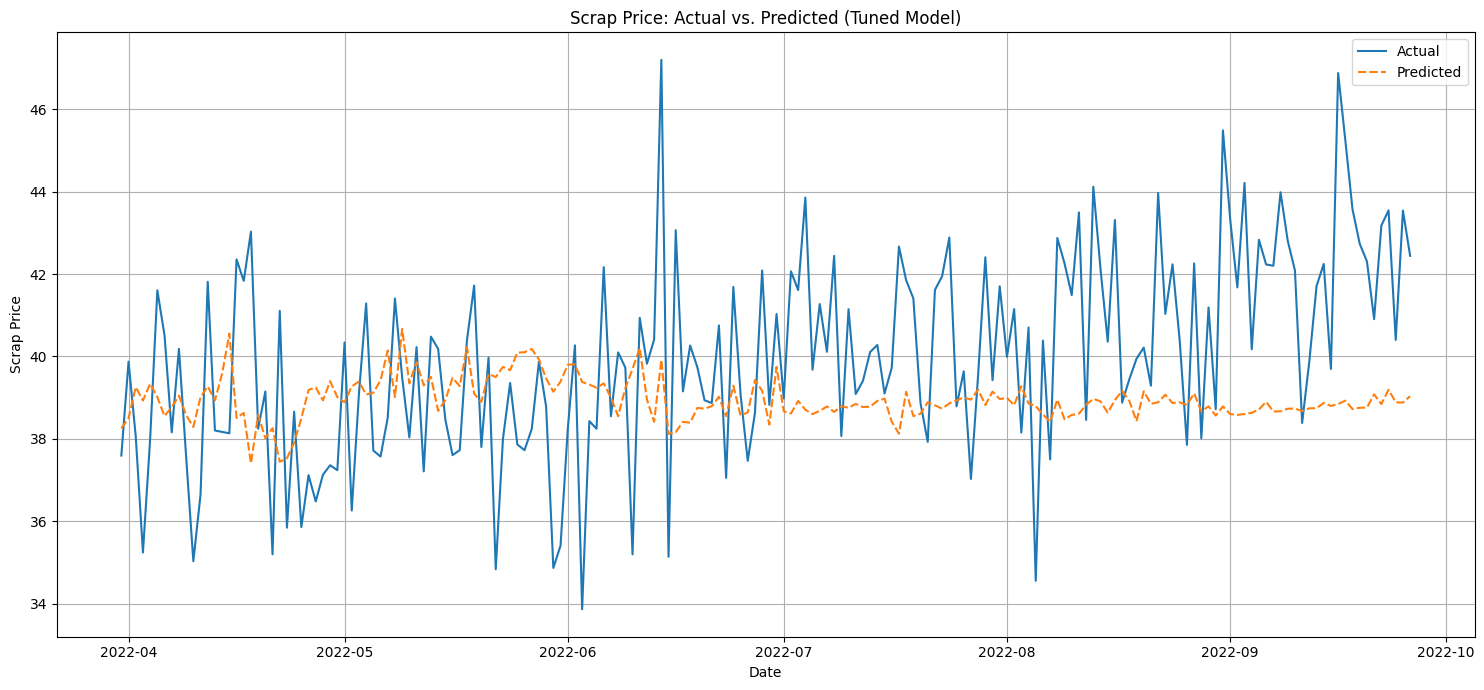

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine actual and predicted values into a single DataFrame for easier plotting
results_df = pd.DataFrame({
    'Actual': true_values_tuned,
    'Predicted': preds_tuned
})

# Plotting Actual vs. Predicted values over time
plt.figure(figsize=(15, 7))
sns.lineplot(data=results_df)
plt.title('Scrap Price: Actual vs. Predicted (Tuned Model)')
plt.xlabel('Date')
plt.ylabel('Scrap Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

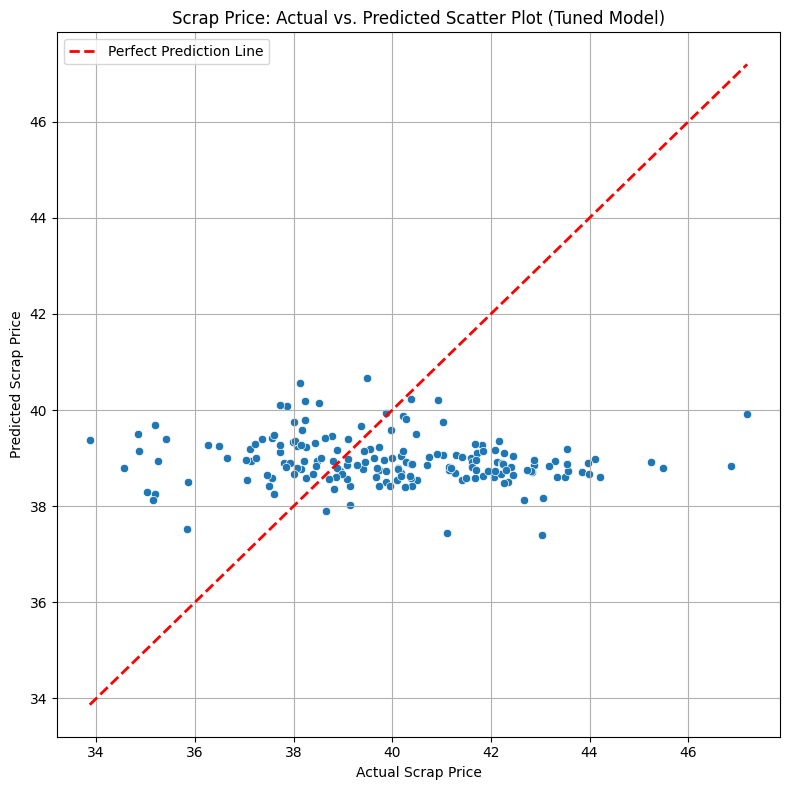

In [ ]:
# Plotting Actual vs. Predicted values as a scatter plot
plt.figure(figsize=(8, 8))
sns.scatterplot(x=results_df['Actual'], y=results_df['Predicted'])
plt.title('Scrap Price: Actual vs. Predicted Scatter Plot (Tuned Model)')
plt.xlabel('Actual Scrap Price')
plt.ylabel('Predicted Scrap Price')
plt.plot([results_df['Actual'].min(), results_df['Actual'].max()],
         [results_df['Actual'].min(), results_df['Actual'].max()],
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calculate residuals for the tuned model
residuals = true_values_tuned - preds_tuned

print("Descriptive Statistics of Residuals:")
display(residuals.describe())


Descriptive Statistics of Residuals:


,scrap_price
count,180.000000
mean,0.992254
std,2.558815
min,-5.510611
25%,-0.923771
50%,0.982525
75%,2.868444
max,8.027855


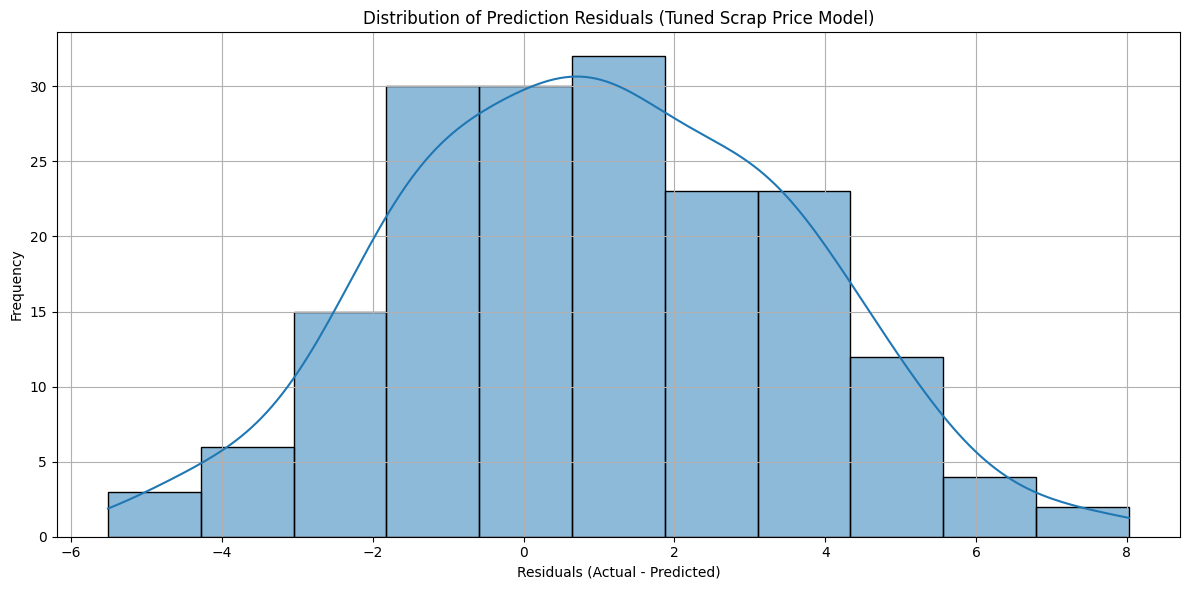

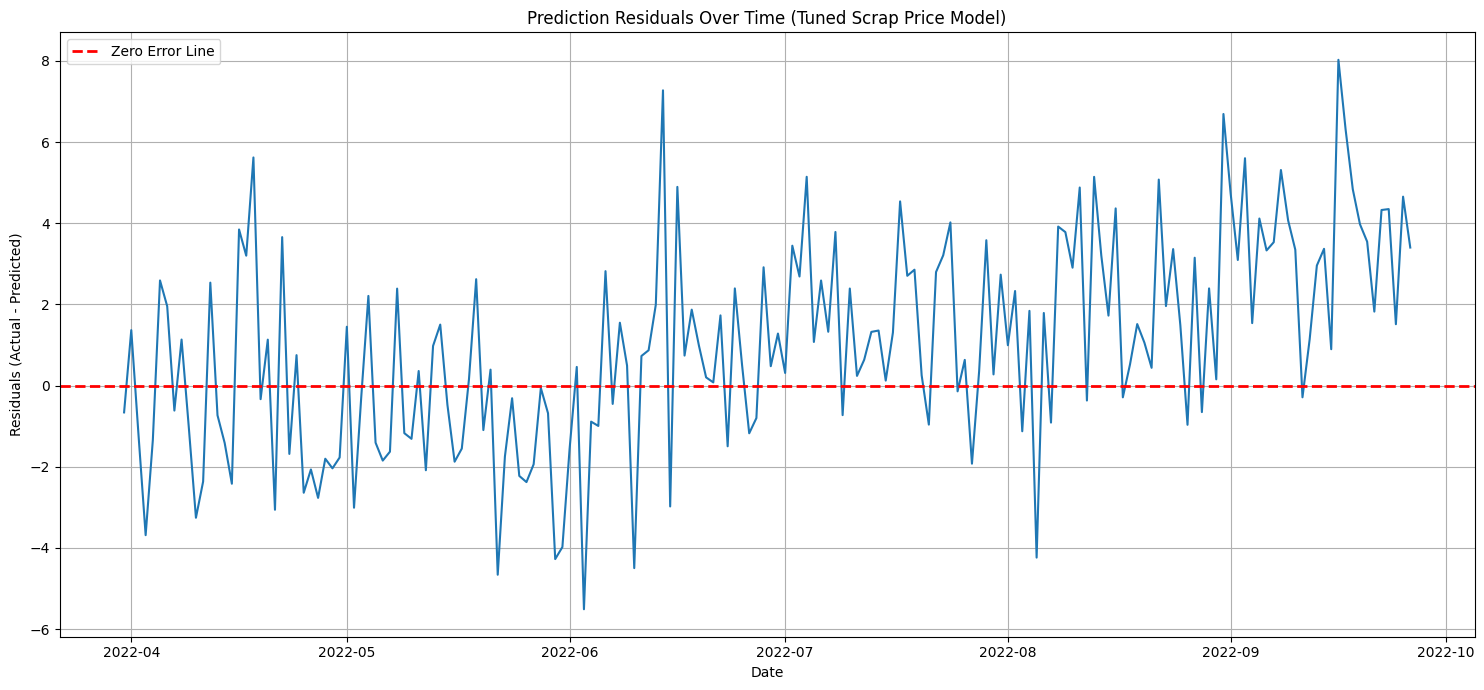

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Residuals Distribution (Histogram)
plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Prediction Residuals (Tuned Scrap Price Model)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting Residuals over Time
plt.figure(figsize=(15, 7))
sns.lineplot(x=residuals.index, y=residuals)
plt.axhline(0, color='red', linestyle='--', lw=2, label='Zero Error Line')
plt.title('Prediction Residuals Over Time (Tuned Scrap Price Model)')
plt.xlabel('Date')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()